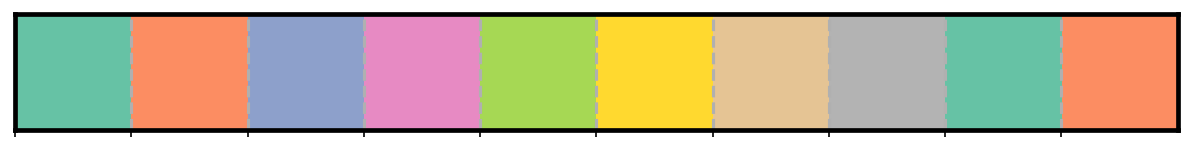

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from iminuit import Minuit
from scipy import stats
from iminuit import cost
from scipy import integrate
import scipy



def setup_plotting(ticksize=14, fontsize=20, figsize=(16, 9), dpi=150):
    """
    Global plotting setup with grey background and custom styling
    """

    # --- Figure defaults ---
    plt.rcParams.update({
        "figure.figsize": figsize,
        "figure.dpi": dpi,
    })

    # --- Background color ---
    plt.rcParams['axes.facecolor'] = "#e8e8e8"

    # --- Fonts ---
    rc = {"font.family": "serif", 
          "mathtext.fontset": "stix"}
    plt.rcParams.update(rc)
    plt.rcParams["font.serif"] = ["Times New Roman"] + plt.rcParams["font.serif"]
    
    plt.rcParams.update({
        "font.size": fontsize,
        "xtick.labelsize": ticksize,
        "ytick.labelsize": ticksize,
    })

    # --- Axes & ticks ---
    plt.rcParams.update({
        "axes.linewidth": 2.25,
        "axes.formatter.limits": (-1, 3),
        "axes.grid": True,
        "legend.facecolor": "white",
    })

    # --- Grid ---
    plt.rcParams.update({
        "grid.linestyle": "--",
        "grid.linewidth": 1.5,
    })

    # --- Color palette ---
    colors = sns.color_palette("Set2", 10)
    sns.set_palette(colors)
    sns.palplot(colors)
    plt.show()

    return colors




def stylize_ticks(fig, ax):
    """
    Apply inward ticks, minor ticks, and label offsets
    """

    ax.xaxis.set_tick_params(which="major", direction="in",
                             width=2.5, length=12, top=True)
    ax.yaxis.set_tick_params(which="major", direction="in",
                             width=2.5, length=12, right=True)

    ax.xaxis.set_tick_params(which="minor", direction="in",
                             width=1.5, length=6, top=True)
    ax.yaxis.set_tick_params(which="minor", direction="in",
                             width=1.5, length=6, right=True)

    # Label offsets
    dx = -3 / 72
    dy = -3 / 72
    x_offset = matplotlib.transforms.ScaledTranslation(dx, 0, fig.dpi_scale_trans)
    y_offset = matplotlib.transforms.ScaledTranslation(0, dy, fig.dpi_scale_trans)

    for label in ax.xaxis.get_majorticklabels():
        label.set_transform(label.get_transform() + y_offset)

    for label in ax.yaxis.get_majorticklabels():
        label.set_transform(label.get_transform() + x_offset)
colors = setup_plotting(ticksize=14, fontsize=20, figsize=(16, 9), dpi=150)

In [ ]:
# setting up grid


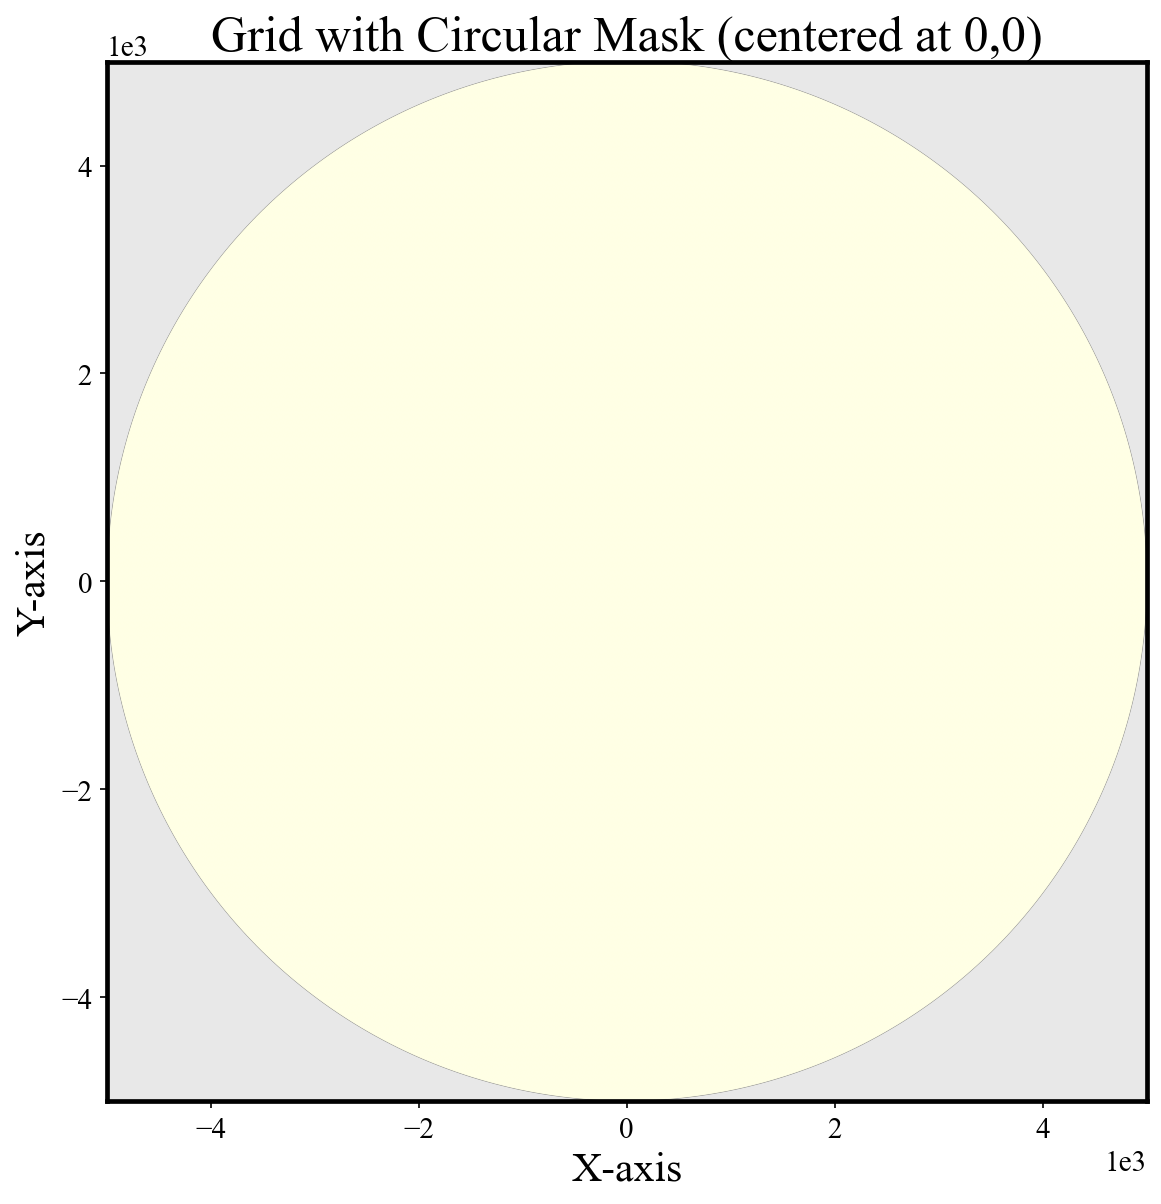

In [ ]:


size = 10000
radius = 5000


x = np.linspace(-radius, radius, size)
y = np.linspace(-radius, radius, size)
X, Y = np.meshgrid(x, y)


distances = np.sqrt(X**2 + Y**2)

# Create grid: 0 inside circle, nan outside
grid = np.full((size, size), np.nan)
grid[distances <= radius] = 0

plt.imshow(grid, cmap="YlOrBr", origin="lower", extent=[-radius, radius, -radius, radius])
plt.title("Grid with Circular Mask (centered at 0,0)")
plt.xlabel("X-axis")
plt.ylabel("Y-axis")
plt.grid(False)  # Disable grid for better visualization
plt.show()

In [ ]:
# one crab movining 200 steps:


def move (position):
    direction = np.random.uniform() * 2 * np.pi  # Random step in x and y
    length=200 
    step = length * np.array([np.cos(direction), np.sin(direction)])
    new_position = position + step
    # Ensure the crab stays within the circular area
    distance = np.linalg.norm(new_position)
    if distance > radius:
        new_position = new_position * (radius / distance)  # Scale to edge
    
    return new_position


In [ ]:
# simultion of 1 crab 200 steps:
position = np.array([3600, -2000])  # Start at the center
trajectory = [position]
np.random.seed(42)  
for _ in range(200):
    position = move(position)
    trajectory.append(position)



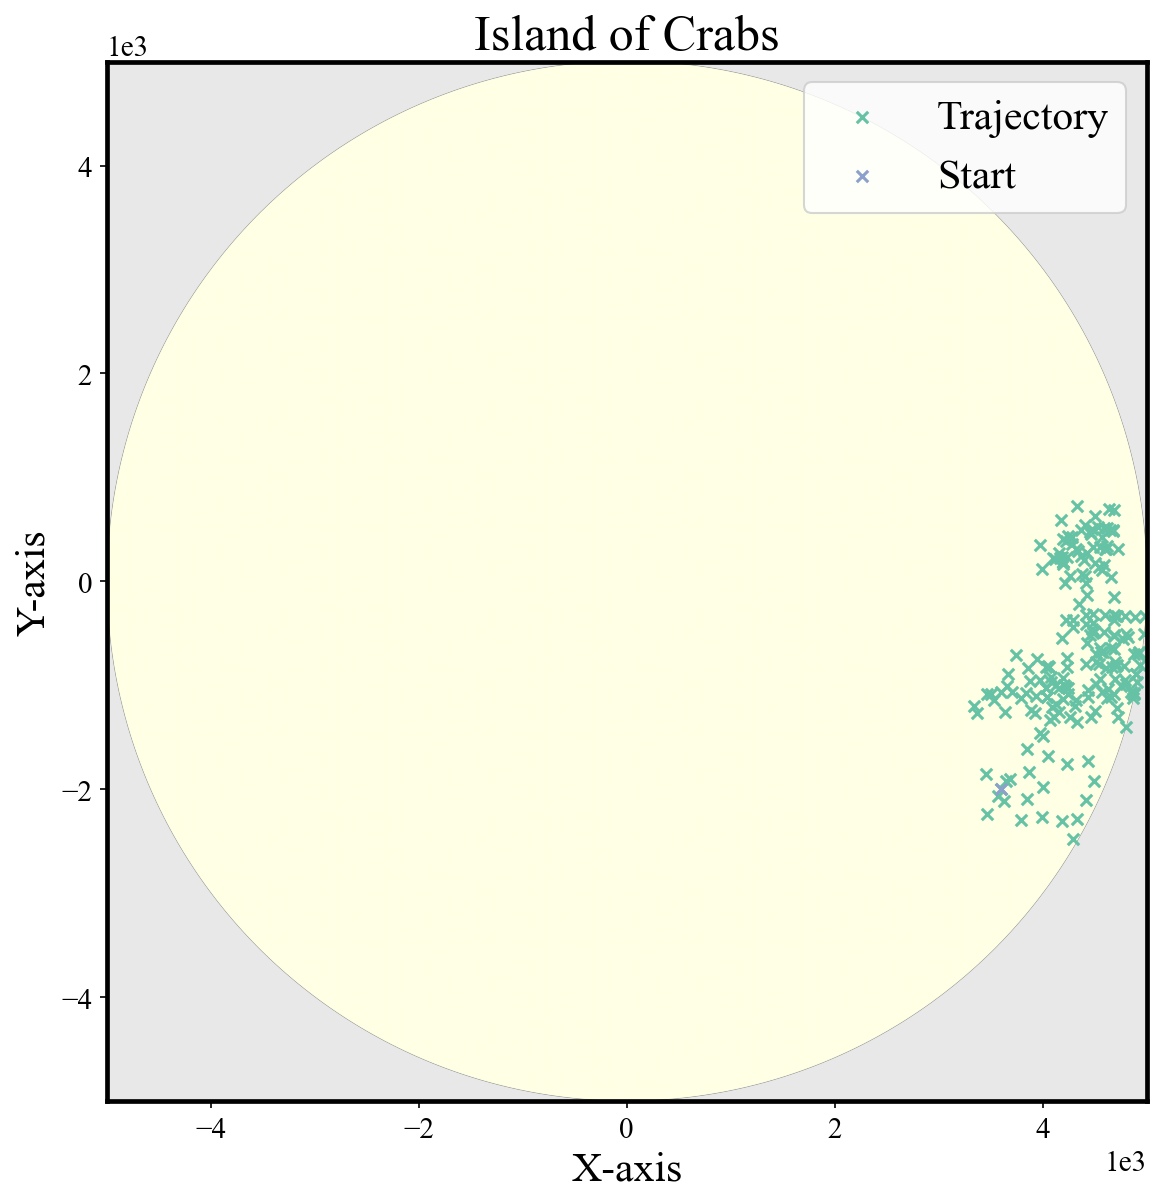

In [ ]:
trajectory = np.array(trajectory)
plt.scatter(trajectory[:, 0], trajectory[:, 1], marker='x', s=30, label='Trajectory')
plt.scatter(trajectory[0, 0], trajectory[0, 1], color=colors[2], marker='x', s=30, label='Start', zorder=5)
plt.imshow(grid, cmap="YlOrBr", origin="lower", extent=[-radius, radius, -radius, radius])
plt.title("Island of Crabs")
plt.xlabel("X-axis")
plt.ylabel("Y-axis")
plt.legend()
plt.grid(False)  # Disable grid for better visualization
plt.show()

In [ ]:
experiments = 501
travel_distances = np.zeros(experiments)   
for e in range(experiments):
    position = np.array([3600, -2000])  # Start at the center
    trajectory = [position]
    length_of_trajectory = 0
    at_edge = False
    while not at_edge:
        position = move(position)
        trajectory.append(position)
        length_of_trajectory += np.linalg.norm(trajectory[-1] - trajectory[-2])
        if np.linalg.norm(position) >= radius:
            at_edge = True
    travel_distances[e] = length_of_trajectory


            

In [ ]:
#convert to km:
travel_distances_km = travel_distances / 1000

[  1.   3.   5.   7.   9.  11.  13.  15.  17.  19.  21.  23.  25.  27.
  29.  31.  33.  35.  37.  39.  41.  43.  45.  47.  49.  51.  53.  55.
  57.  59.  61.  63.  65.  67.  69.  71.  73.  75.  77.  79.  81.  83.
  85.  87.  89.  91.  93.  95.  97.  99. 101. 103. 105. 107. 109. 111.
 113. 115. 117. 119. 121. 123. 125. 127. 129. 131. 133. 135. 137. 139.
 141. 143. 145. 147. 149. 151. 153. 155. 157. 159. 161. 163. 165. 167.
 169. 171. 173. 175. 177. 179. 181. 183. 185. 187. 189. 191. 193. 195.
 197. 199.]


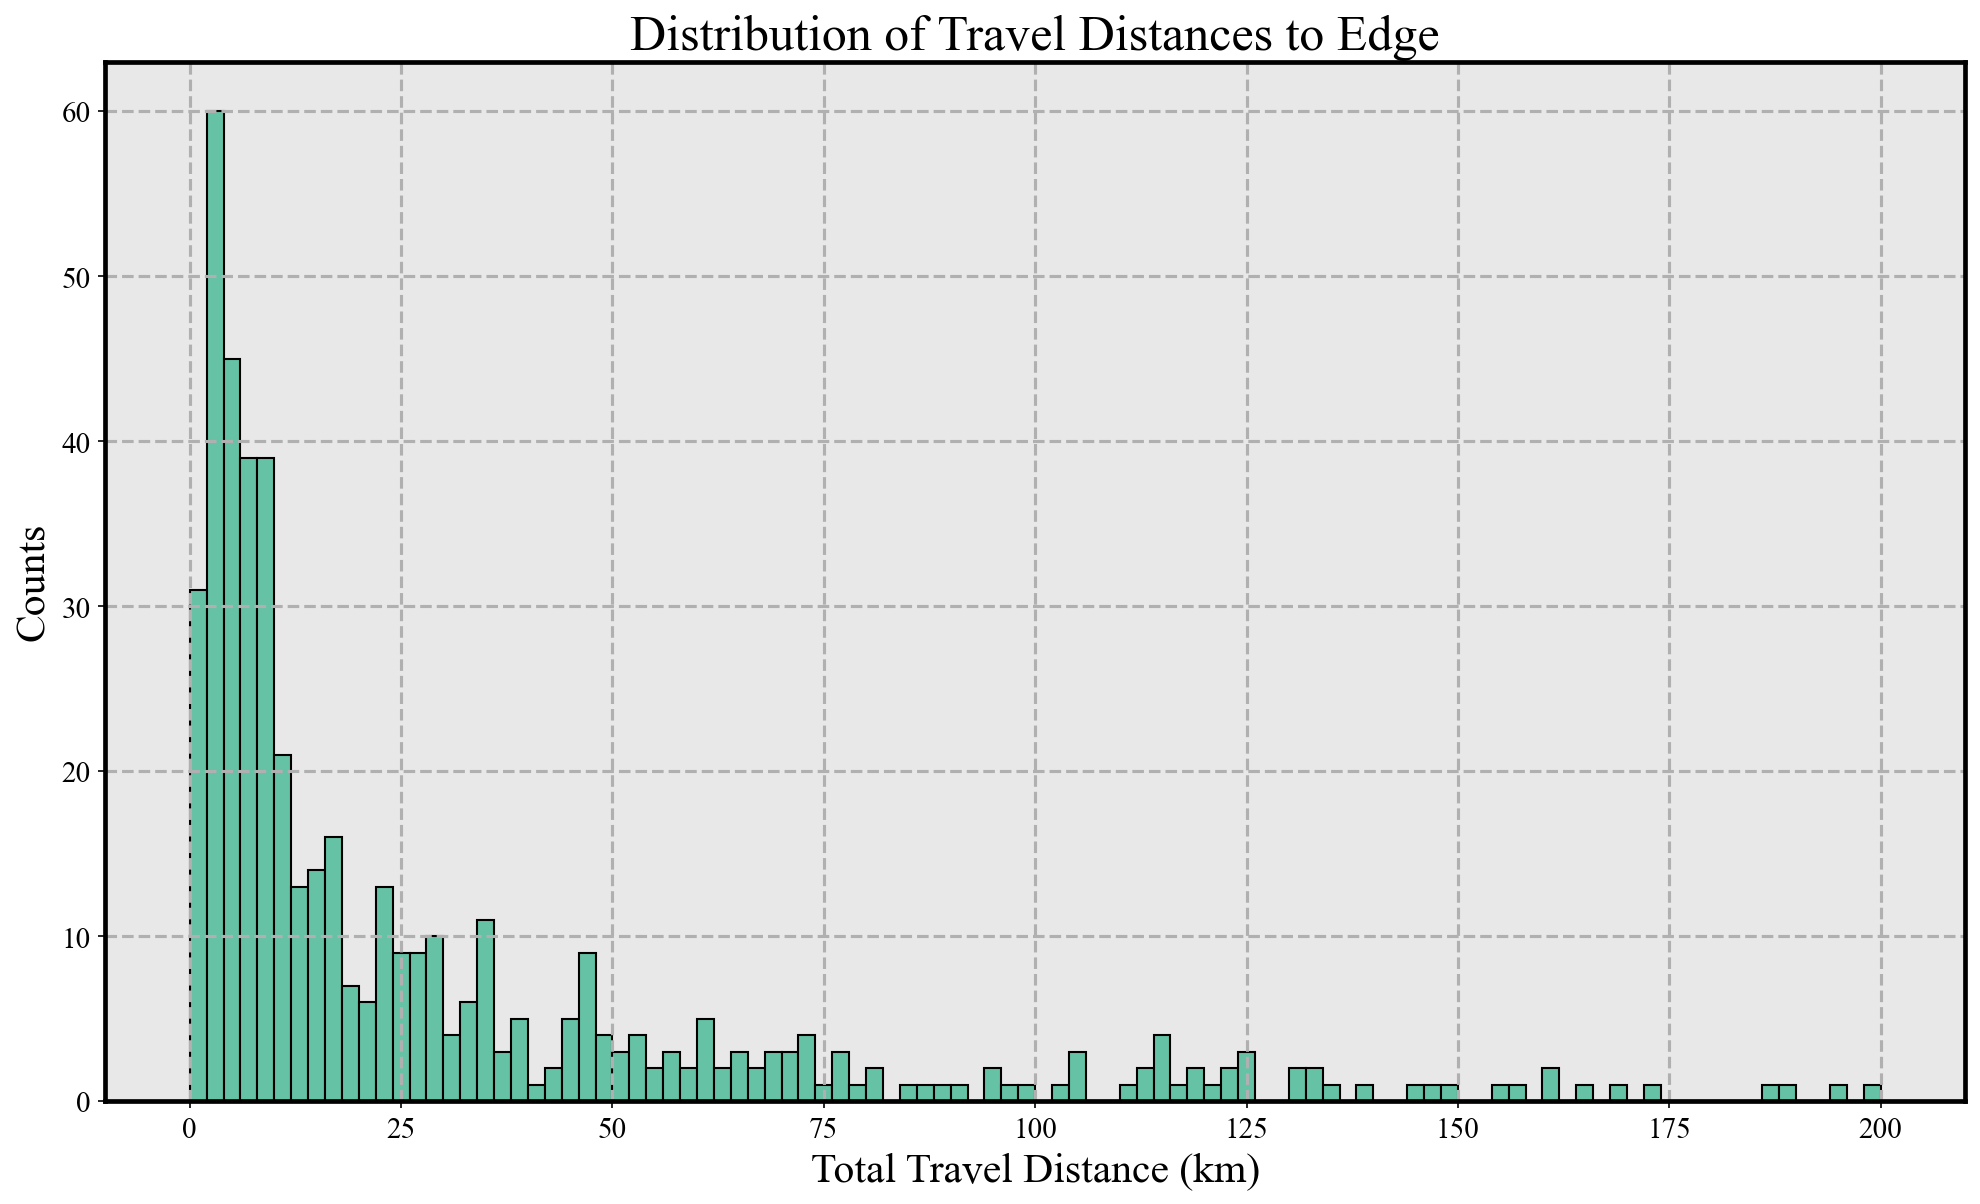

In [ ]:
xrange = (0,200)
Nbins = 100 
counts, edges = np.histogram(travel_distances_km, bins=Nbins, range=xrange, density=False)
bin_centers = (edges[:-1] + edges[1:]) / 2
bin_width = edges[1] - edges[0]
plt.bar(bin_centers, counts, width=edges[1] - edges[0], color=colors[0], edgecolor='black')
plt.title("Distribution of Travel Distances to Edge")
plt.xlabel("Total Travel Distance (km)")
plt.ylabel("Counts")
print(bin_centers)
plt.show()

In [ ]:
def battle(position1, position2):
    
    distance = np.linalg.norm(position1 - position2)

    if distance < 175:  # If crabs are within 175 units, they fight
        return "fight"
    else:
        return "no fight"

In [ ]:
initial_positions = np.genfromtxt('CrabStartPositions.txt', delimiter=" ")
initial_positions = initial_positions * 1000  # Convert from km to units
print(initial_positions)

[[ 1844.98037421  3893.01702477]
 [-3258.88674436 -2433.24367631]
 [  908.8079975   -861.28283165]
 [ 1691.86640126  1184.10858245]
 [  -10.15231634  -395.53441392]
 [-1871.38281039  -448.70484533]
 [-2053.17251963   800.81545359]
 [ 1771.60884295    89.34004937]
 [-2050.04631137 -3422.70083713]
 [-3299.28926362   687.06488315]
 [ 1260.4467649   2075.51773846]
 [ 3083.07475413   147.20063628]
 [-3373.15178897  2778.8123895 ]
 [ -829.07391023 -1929.19459488]
 [ 2925.82253923 -1984.87642496]
 [  465.17725444 -4355.23961487]
 [ 1507.93615854 -2624.90633933]
 [-1415.24273644  2235.03301889]
 [ 2840.86403309 -3081.10502815]
 [  459.1153271   3987.52608517]]


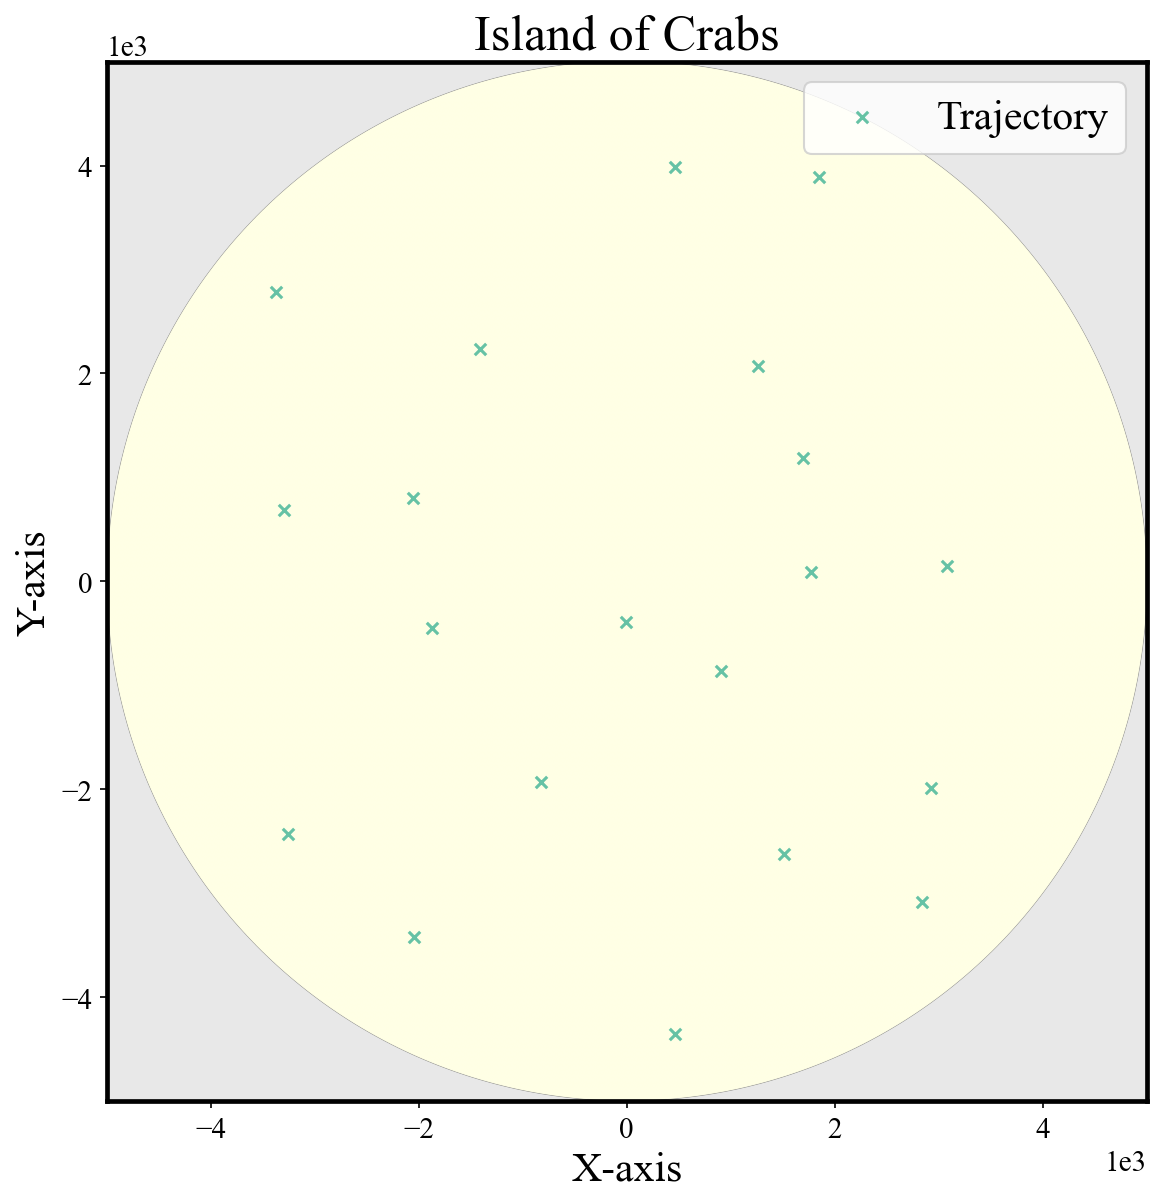

In [ ]:

plt.scatter(initial_positions[:, 0], initial_positions[:, 1], marker='x', s=30, label='Trajectory')

plt.imshow(grid, cmap="YlOrBr", origin="lower", extent=[-radius, radius, -radius, radius])
plt.title("Island of Crabs")
plt.xlabel("X-axis")
plt.ylabel("Y-axis")
plt.legend()
plt.grid(False)  # Disable grid for better visualization
plt.show()

In [ ]:
N_experiments = 6000
recording_mass_of_largest = np.zeros(N_experiments)  # To record final masses of crabs
recording_n_crabs = np.zeros(N_experiments)  # To record number of crabs alive at the end of each experiment
for exp in range(N_experiments):
    mass_crab = np.ones(len(initial_positions), dtype=int)  # Track alive crabs

    current_position = initial_positions.copy()

    for _ in range(200): #number of days to simulate
        if np.sum(mass_crab) != 20:
            raise ValueError("Number of crabs has changed, check the battle function.")
        for crab_idx, crab in enumerate(current_position): # Loop over all crabs
            if mass_crab[crab_idx] > 0: #check if alive
                current_position[crab_idx] = move(crab) 
        
        battles = []
        for i in range(len(current_position)):
            for j in range(i + 1, len(current_position)):  # Only j > i to avoid double-counting
                if mass_crab[i] > 0 and mass_crab[j] > 0:  # Both alive
                    distance = np.linalg.norm(current_position[i] - current_position[j])

                    if distance < 175:  # If crabs are within 175 units, they fight
                        battles.append((distance, i, j))  # Store indices of battling crabs
                        




        battles.sort()
        for distance, i, j in battles:
            if mass_crab[i] == 0 or mass_crab[j] == 0:
                continue
            if mass_crab[i] < mass_crab[j]:  # Crab i is weaker
                chance = mass_crab[i]**2/(mass_crab[i]**2 + mass_crab[j]**2)
                outcome = np.random.rand()  # Random number between 0 and 1

                if outcome > chance:
                    mass_crab[j] += mass_crab[i]  # Crab j gains mass
                    mass_crab[i] = 0  # Crab i dies
                    

            elif mass_crab[j] < mass_crab[i]:  # Crab j is weaker
                chance = mass_crab[j]**2/(mass_crab[i]**2 + mass_crab[j]**2)
                outcome = np.random.rand()  # Random number between 0 and 1
                            
                if outcome > chance:
                        mass_crab[i] += mass_crab[j]  # Crab i gains mass
                        mass_crab[j] = 0  # Crab j dies
                                

            else: #equal mass, 50/50 chance
                outcome = np.random.rand()  # Random number between 0 and 1
                if outcome > 0.5:
                    mass_crab[j] += mass_crab[i]  # Crab j gains mass
                    mass_crab[i] = 0  # Crab i dies
                                
                else:
                    mass_crab[i] += mass_crab[j]  # Crab i gains mass
                    mass_crab[j] = 0  # Crab j dies
                                
                    
            #update current position of crab i after all battles
        mask = (mass_crab == 0)  # update position of dead crabs
        current_position[mask] = np.nan  # Set position of dead crabs to NaN
    recording_mass_of_largest[exp] = np.max(mass_crab)
    recording_n_crabs[exp] = np.sum(mass_crab > 0)

    




In [ ]:
recording_mass_of_largest


array([5., 3., 3., ..., 3., 6., 7.], shape=(6000,))

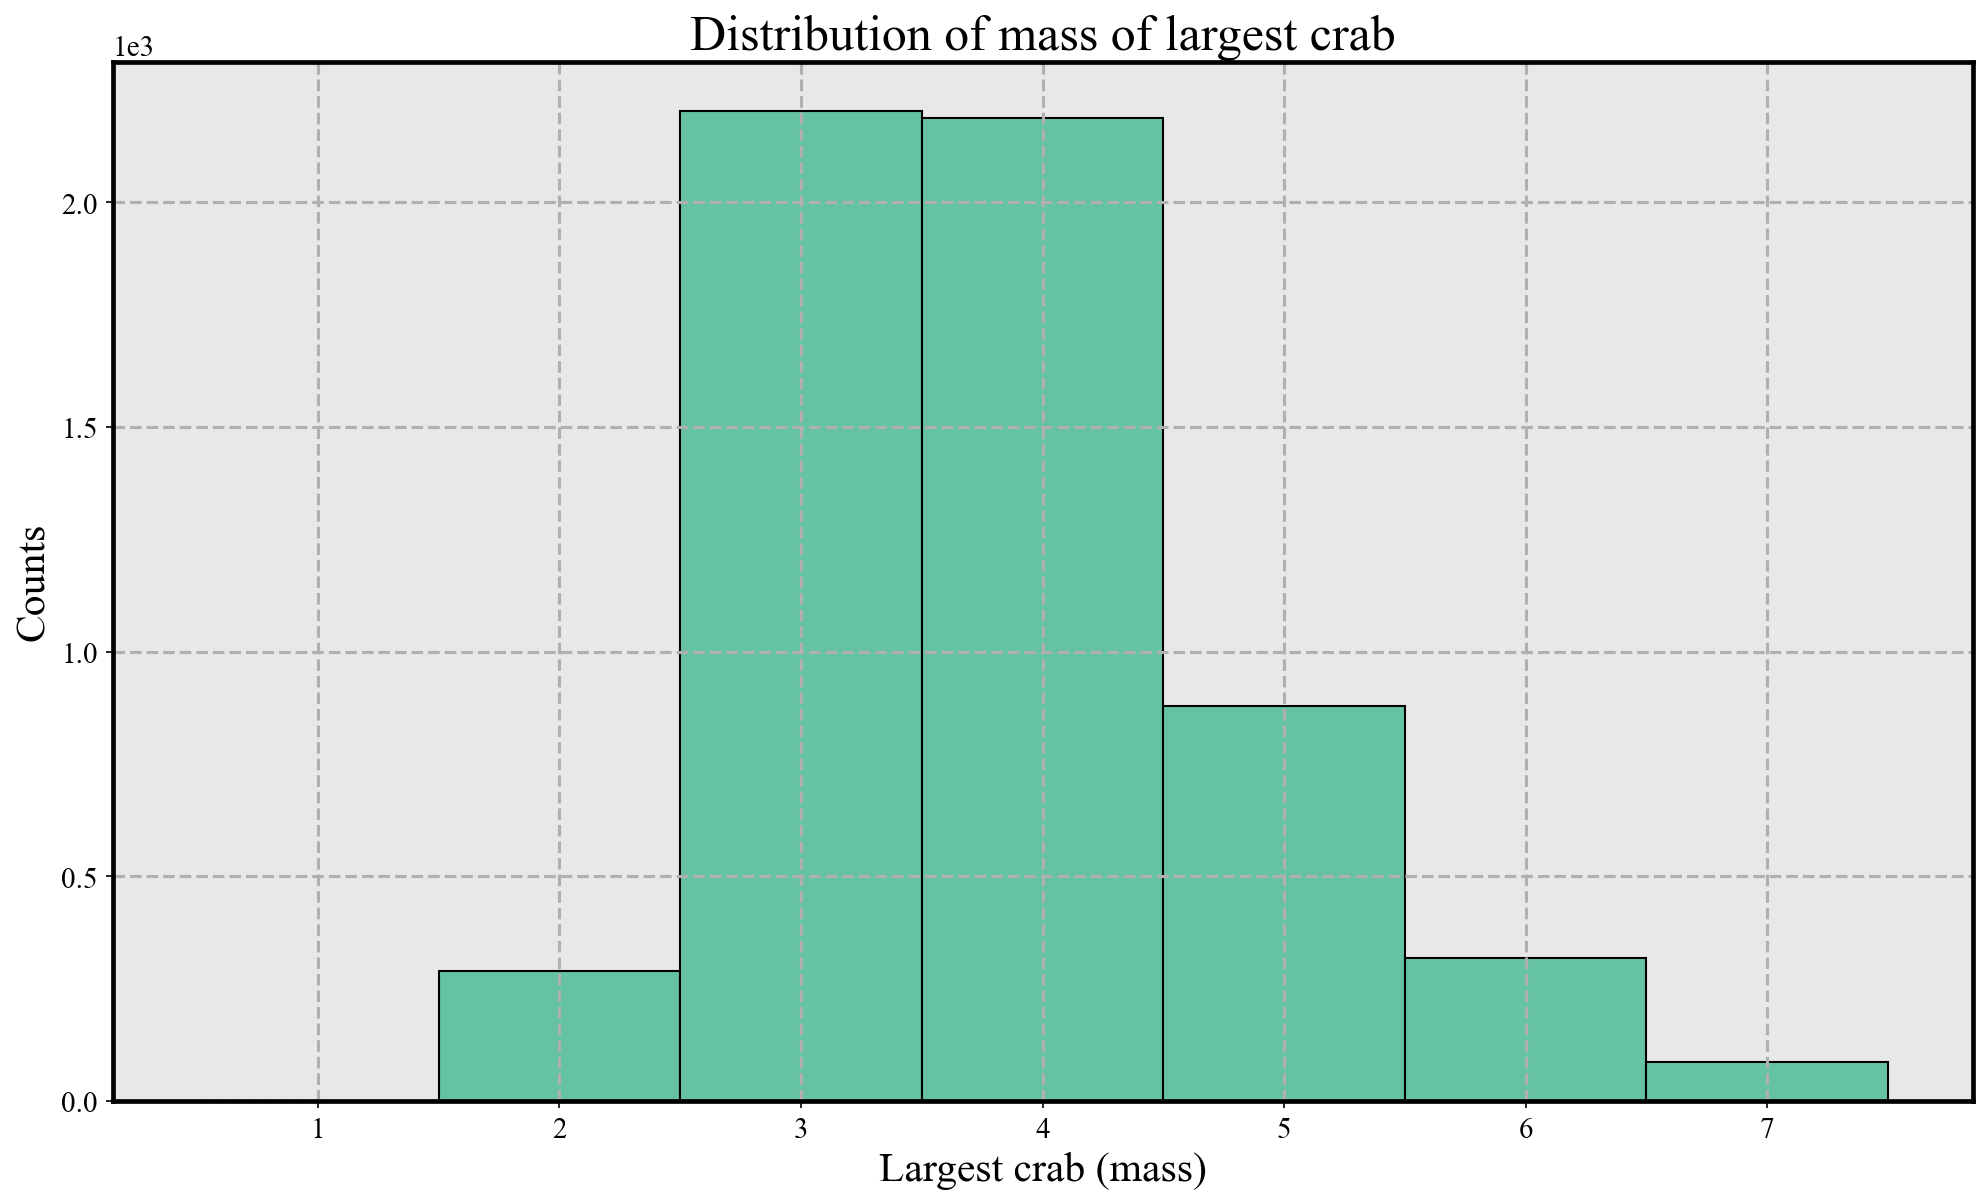

In [ ]:
Nbins = 7
xrange = (0.5, 7.5)
counts_mass, edges_mass = np.histogram(recording_mass_of_largest, bins=Nbins, range=xrange, density=False)
bin_centers_mass = (edges_mass[:-1] + edges_mass[1:]) / 2
bin_width_mass = edges_mass[1] - edges_mass[0]
plt.bar(bin_centers_mass, counts_mass, width=bin_width_mass, color=colors[0], edgecolor='black')
plt.title("Distribution of mass of largest crab")
plt.xlabel("Largest crab (mass)")
plt.ylabel("Counts")
plt.show()

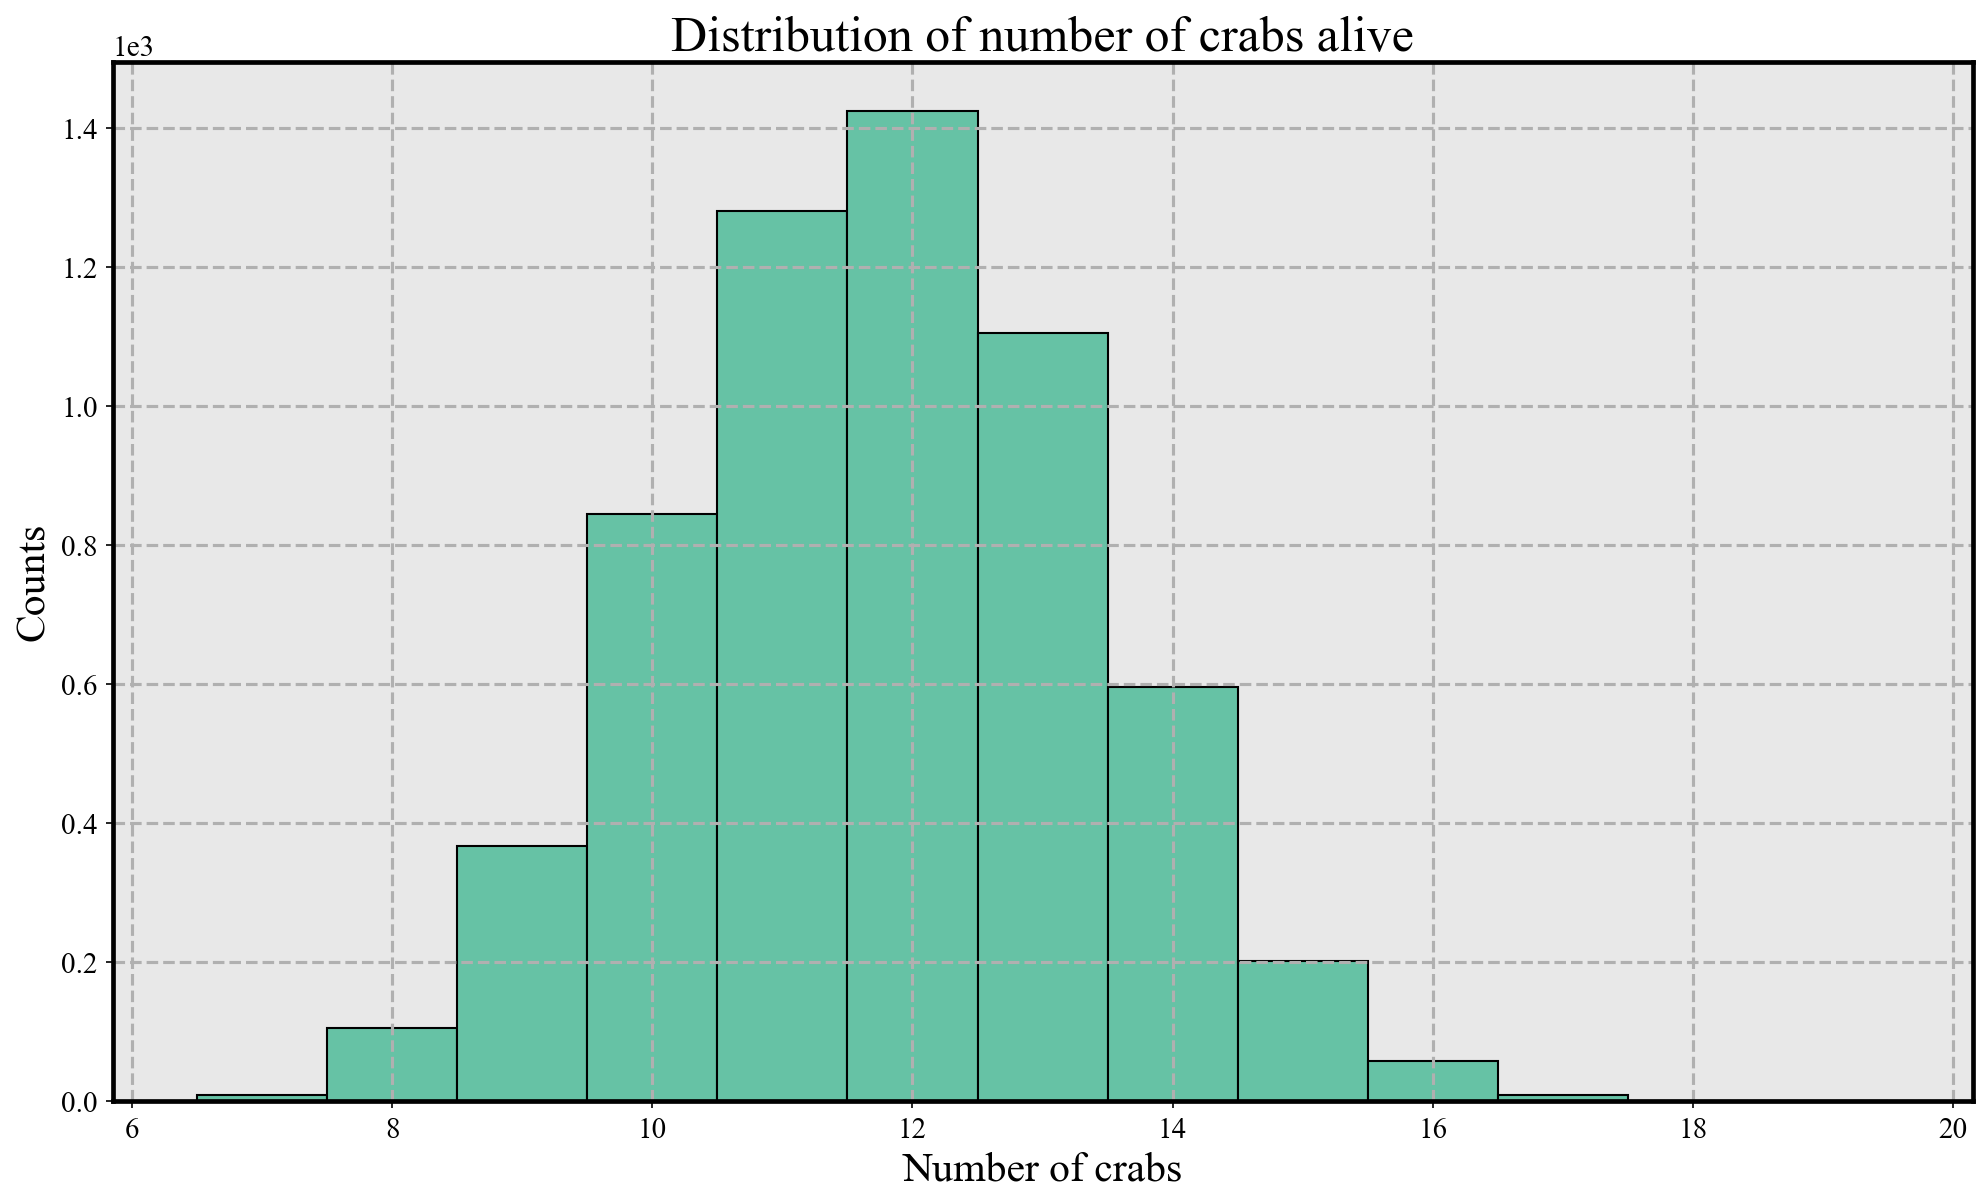

In [ ]:
Nbins = 13
xrange = (6.5, 19.5)
counts_mass, edges_mass = np.histogram(recording_n_crabs, bins=Nbins, range=xrange, density=False)
bin_centers_mass = (edges_mass[:-1] + edges_mass[1:]) / 2
bin_width_mass = edges_mass[1] - edges_mass[0]
plt.bar(bin_centers_mass, counts_mass, width=bin_width_mass, color=colors[0], edgecolor='black')
plt.title("Distribution of number of crabs alive")
plt.xlabel("Number of crabs")
plt.ylabel("Counts")
plt.show()

In [ ]:
N_experiments = 6000
recording_mass_of_largest = np.zeros(N_experiments)  # To record final masses of crabs
recording_n_crabs = np.zeros(N_experiments)  
dist_days = np.zeros(N_experiments)  
for exp in range(N_experiments):
    mass_crab = np.ones(len(initial_positions), dtype=int)  # Track alive crabs

    current_position = initial_positions.copy()
    days = 0
    while np.sum(mass_crab > 0) > 10: #number of days to simulate
        days += 1
        if np.sum(mass_crab) != 20:
            raise ValueError("Number of crabs has changed, check the battle function.")
        for crab_idx, crab in enumerate(current_position): 
            if mass_crab[crab_idx] > 0: #check if alive
                current_position[crab_idx] = move(crab) 
        
        battles = []
        for i in range(len(current_position)):
            for j in range(i + 1, len(current_position)):  
                if mass_crab[i] > 0 and mass_crab[j] > 0:  
                    distance = np.linalg.norm(current_position[i] - current_position[j])

                    if distance < 175:  
                        battles.append((distance, i, j))  
                        




        battles.sort()
        for distance, i, j in battles:
            if mass_crab[i] == 0 or mass_crab[j] == 0:
                continue
            if mass_crab[i] < mass_crab[j]:  
                chance = mass_crab[i]**2/(mass_crab[i]**2 + mass_crab[j]**2)
                outcome = np.random.rand()  

                if outcome > chance:
                    mass_crab[j] += mass_crab[i]  
                    mass_crab[i] = 0  
                    

            elif mass_crab[j] < mass_crab[i]:  
                chance = mass_crab[j]**2/(mass_crab[i]**2 + mass_crab[j]**2)
                outcome = np.random.rand()  
                            
                if outcome > chance:
                        mass_crab[i] += mass_crab[j]  
                        mass_crab[j] = 0  
                                

            else: #equal mass, 50/50 chance
                outcome = np.random.rand()  
                if outcome > 0.5:
                    mass_crab[j] += mass_crab[i]  
                    mass_crab[i] = 0  
                                
                else:
                    mass_crab[i] += mass_crab[j]  
                    mass_crab[j] = 0  
                                
                    
            #update current position of crab i after all battles
        mask = (mass_crab == 0)  # update position of dead crabs
        current_position[mask] = np.nan  # Set position of dead crabs to NaN
    recording_mass_of_largest[exp] = np.max(mass_crab)
    recording_n_crabs[exp] = np.sum(mass_crab > 0)
    dist_days[exp] = days  # Record number of days until only 10 crabs are left

    




In [ ]:
lower_percentile = (100 - 68.27) / 2  # 15.865
upper_percentile = (100 + 68.27) / 2  # 84.135

lower_bound = np.percentile(dist_days, lower_percentile)
upper_bound = np.percentile(dist_days, upper_percentile)

mean_days = np.mean(dist_days)

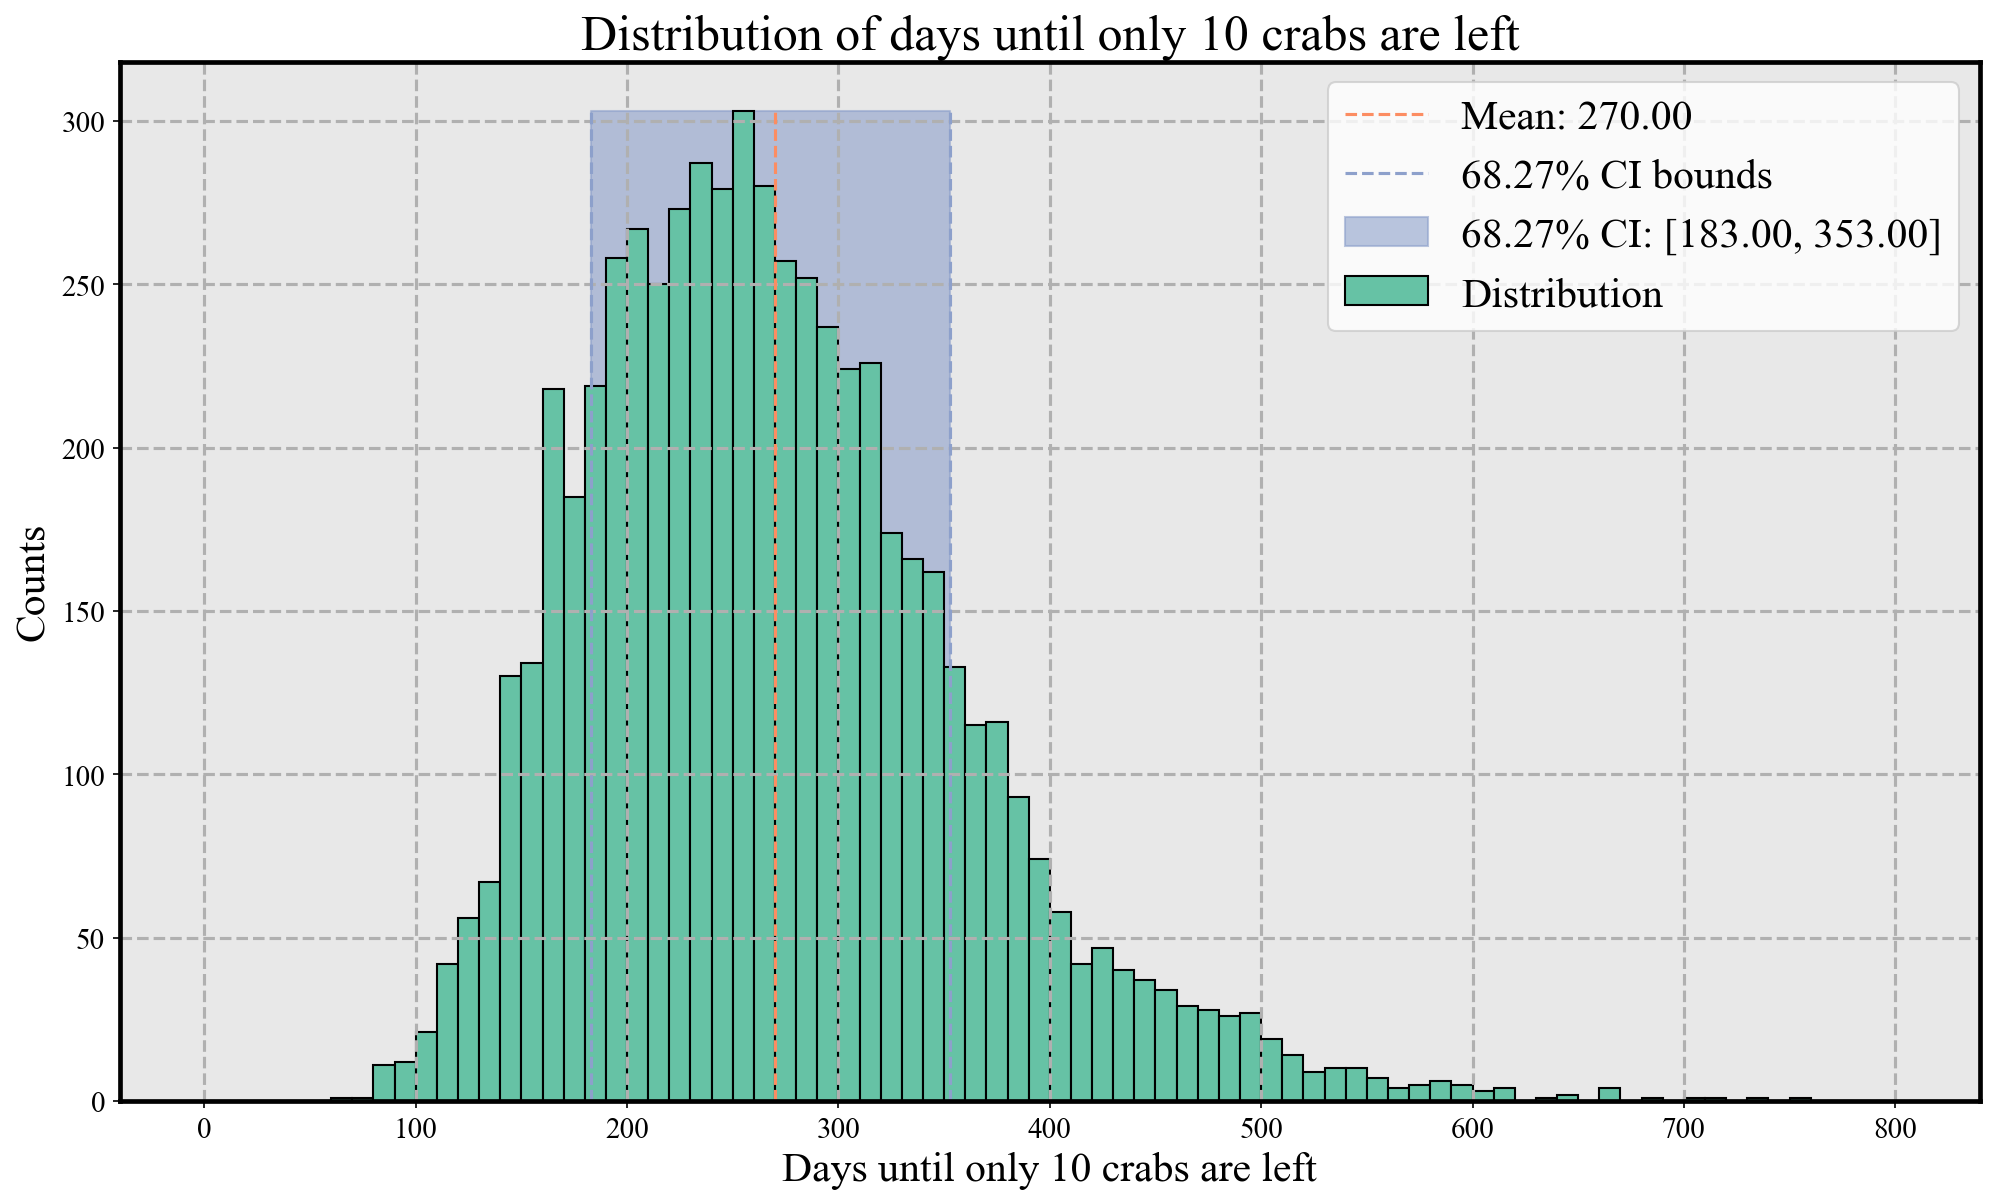

In [ ]:
Nbins = 80
xrange = (0, 800)
counts_days, edges_days = np.histogram(dist_days, bins=Nbins, range=xrange, density=False)
bin_centers_days = (edges_days[:-1] + edges_days[1:]) / 2
bin_width_days = edges_days[1] - edges_days[0]
plt.vlines(mean_days, ymin=0, ymax=max(counts_days), colors=colors[1], linestyles='dashed', label=f"Mean: {mean_days:.2f}")
plt.vlines(lower_bound, ymin=0, ymax=max(counts_days), colors=colors[2], linestyles='dashed', label="68.27% CI bounds")
plt.vlines(upper_bound, ymin=0, ymax=max(counts_days), colors=colors[2], linestyles='dashed')
plt.fill_betweenx([0, max(counts_days)], x1=lower_bound, x2=upper_bound, color=colors[2], alpha=0.6, label=f"68.27% CI: [{lower_bound:.2f}, {upper_bound:.2f}]")
#plt.hlines(max(counts_days)/2, xmin=lower_bound, xmax=upper_bound, colors=colors[1], linestyles='dashed', label=f"68.27% CI: [{lower_bound:.2f}, {upper_bound:.2f}]")
plt.bar(bin_centers_days, counts_days, width=bin_width_days, color=colors[0], edgecolor='black', label="Distribution")
plt.title("Distribution of days until only 10 crabs are left")
plt.xlabel("Days until only 10 crabs are left")
plt.ylabel("Counts")
plt.legend()
plt.show()

87.0043333333333
82.9956666666667
